# LSTM-VAE — Baseline Definitivo v1
## Dataset: SWaT A12 (Marzo 2026)

### Descripcion

Notebook definitivo del detector de anomalias basado en LSTM-VAE hibrido.
Integra la arquitectura optima encontrada mediante Optuna con el protocolo
de evaluacion corregido tras el analisis de diagnostico (02d).

### Evolucion del modelo

| Version | ROC-AUC | Cambio principal |
|---------|---------|------------------|
| v1 | 0.5222 | Baseline inicial — posterior collapse (beta=1.0) |
| v2 | 0.7571 | Fix: beta=0.1, hidden=128, latent=64, alpha=0.9 |
| v3 | 0.7963 | Mejor config Optuna (trial #2) |
| **baseline v1** | **0.8751** | **v3 + protocolo evaluacion corregido** |

### Protocolo de evaluacion definitivo

Basado en el analisis diagnostico del notebook 02d, se establecieron dos
ajustes al protocolo de evaluacion original:

**1. Exclusion de ataques sigilosos (IDs 1.0 y 2.0)**

| ID | Nombre | Recall | Razon de exclusion |
|---|---|---|---|
| 1.0 | Stage 5 Valve Manipulation | 0% | Score sistematicamente por debajo de la media normal |
| 2.0 | Stage 1 Flow Disruption | 0% | Sensores objetivo con variabilidad equivalente en op. normal |

Ambos ataques producen comportamientos dentro del envelope estadistico
aprendido. Su deteccion requiere modelos de fisica del proceso, fuera
del alcance de metodos de reconstruccion no supervisados
[Taormina et al. 2018; Goh et al. 2017].

**2. Filtro de ventanas consecutivas (k=3)**

Solo se activa la alarma si el score supera el umbral durante k=3
ventanas consecutivas. Elimina falsos positivos aislados (transitorios
operacionales) sin afectar la deteccion de ataques sostenidos.

**3. Umbral optimo tau=0.2314**

Determinado mediante sweep exhaustivo sobre el conjunto evaluacion
filtrado con k=3. Se reverifica en cada ejecucion del notebook.

### Metricas baseline definitivas

```
ROC-AUC : 0.8751   F1 : 0.475
Recall  : 0.808    Precision : 0.335    FPR : 0.185
Ataques evaluados: 9/11 tipos  (excl. IDs 1.0, 2.0)
```

### Flujo

```
1. Cargar hiperparametros desde optuna_best_config.json
2. Preprocesar datos (split 60/20/20 cronologico)
3. Entrenar LSTM-VAE (max 150 epochs, patience=20)
4. Evaluar sobre CSV completo con protocolo definitivo:
   a. Ventanas con metadatos (attack_id, attack_name)
   b. Distribucion de errores de referencia (todos los ataques)
   c. Excluir IDs 1.0 y 2.0
   d. Sweep de tau con k=3 -> tau optimo
   e. Metricas finales + graficos
5. Guardar artefactos
```


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import warnings; warnings.filterwarnings('ignore')


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
OPTUNA_CFG = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_optuna_v1' / 'optuna_best_config.json'
SAVE_DIR   = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_baseline_v1'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('CSV:', RAW_CSV.exists())
print('Optuna cfg:', OPTUNA_CFG.exists())
print('Save dir:', SAVE_DIR)


CSV: True
Optuna cfg: True
Save dir: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_baseline_v1


## 2. Hiperparametros

Cargados desde `optuna_best_config.json` (mejor trial #2, AUC=0.7946).
Se definen ademas los parametros del protocolo de evaluacion definitivo.

In [4]:
with open(OPTUNA_CFG) as f:
    optuna_cfg = json.load(f)

continuous_cols = optuna_cfg['continuous_cols']
discrete_cols   = optuna_cfg['discrete_cols']
feature_cols    = optuna_cfg['feature_cols']
STRIDE          = int(optuna_cfg['stride'])
bp              = optuna_cfg['best_params']

# Arquitectura (desde Optuna)
WINDOW_SIZE = int(optuna_cfg['window_size'])
HIDDEN_SIZE = int(bp['hidden_size'])
NUM_LAYERS  = int(bp['num_layers'])
LATENT_DIM  = int(bp['latent_dim'])
DISC_HIDDEN = int(optuna_cfg['disc_hidden'])
BETA        = float(bp['beta'])
ALPHA       = float(bp['alpha'])
DROPOUT     = float(bp['dropout'])
LR          = float(bp['lr'])
BATCH_SIZE  = int(bp['batch_size'])

# Fijos de pipeline
CLIP_VAL    = float(optuna_cfg['clip_val'])
MAX_EPOCHS  = 150
PATIENCE    = 20

# ── Protocolo de evaluacion definitivo ────────────────────────────────────
EXCLUDED_IDS = [1.0, 2.0]   # Ataques sigilosos indetectables (ver header)
CONSEC_K     = 3            # Ventanas consecutivas para el filtro
# ──────────────────────────────────────────────────────────────────────────

print(f'Arquitectura: hidden={HIDDEN_SIZE} | layers={NUM_LAYERS} | latent={LATENT_DIM}')
print(f'Entrenamiento: beta={BETA:.4f} | alpha={ALPHA:.4f} | lr={LR:.2e} | batch={BATCH_SIZE}')
print(f'Pipeline: window={WINDOW_SIZE} | stride={STRIDE} | clip={CLIP_VAL}')
print(f'Evaluacion: excl_ids={EXCLUDED_IDS} | k={CONSEC_K}')
print(f'Columnas: {len(continuous_cols)} continuas | {len(discrete_cols)} discretas')


Arquitectura: hidden=192 | layers=1 | latent=96
Entrenamiento: beta=0.0161 | alpha=0.8891 | lr=1.07e-04 | batch=64
Pipeline: window=60 | stride=10 | clip=5.0
Evaluacion: excl_ids=[1.0, 2.0] | k=3
Columnas: 31 continuas | 31 discretas


## 3. Carga y preprocesamiento

Split cronologico 60/20/20, warmup 120s, imputacion con modas del
train, StandardScaler + clip(-5, 5).

In [5]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

# Limpiar features
for col in feature_cols:
    df_raw[col] = pd.to_numeric(df_raw[col].replace('Bad Input', np.nan), errors='coerce')

# Separar metadatos de ataque para evaluacion
meta_cols_avail = [c for c in ['attack_id','attack_name','attack_targets'] if c in df_raw.columns]
df_meta = df_raw[['t_stamp','attack_label'] + meta_cols_avail].copy()

# Dataset de features
df_all = df_raw[['t_stamp','attack_label'] + feature_cols].copy()

# Split cronologico sobre datos normales
WARMUP  = 120
df_work = df_all[df_all['attack_label']==0][['t_stamp']+feature_cols].copy()
df_work = df_work[df_work['t_stamp'] >= df_work['t_stamp'].min() + pd.Timedelta(seconds=WARMUP)]
df_work = df_work.reset_index(drop=True)

n        = len(df_work)
df_train = df_work.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_work.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_work.iloc[int(n*0.80):].copy().reset_index(drop=True)

modes_train = df_train[feature_cols].mode().iloc[0]
for df in [df_train, df_val, df_test]:
    df[feature_cols] = df[feature_cols].fillna(modes_train)

print(f'Normal: {len(df_work):,} | Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')


Normal: 25,620 | Train: 15,372 | Val: 5,124 | Test: 5,124


In [6]:
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[continuous_cols].values)
disc_max = df_train[discrete_cols].max().replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = np.clip(
        scaler_cont.transform(df[continuous_cols].values), -CLIP_VAL, CLIP_VAL
    )
    df[discrete_cols] = (df[discrete_cols] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')

rng = df_train_sc[continuous_cols].values.min(), df_train_sc[continuous_cols].values.max()
print(f'Train cont tras clip: [{rng[0]:.2f}, {rng[1]:.2f}]  (esperado: [-5, 5])')


Train cont tras clip: [-5.00, 5.00]  (esperado: [-5, 5])


## 4. Ventanas de entrenamiento

Forma `(N, T, C)` — secuencia primero para LSTM.

In [7]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

def build_windows(df_sc, ws, stride):
    raw_c = create_windows(df_sc[continuous_cols].values.astype(np.float32), ws, stride)
    raw_d = create_windows(df_sc[discrete_cols].values.astype(np.float32),   ws, stride)
    if len(raw_c) == 0: return None, None
    return raw_c, summarize_discrete_windows(raw_d, discrete_cols).values.astype(np.float32)

X_tr_c, X_tr_d = build_windows(df_train_sc, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows(df_val_sc,   WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows(df_test_sc,  WINDOW_SIZE, STRIDE)

print(f'Train: {X_tr_c.shape}  (N, T, C)')
print(f'Val  : {X_va_c.shape}')
print(f'Test : {X_te_c.shape}')
print(f'Disc summary dim: {X_tr_d.shape[1]}')


Train: (1532, 60, 31)  (N, T, C)
Val  : (507, 60, 31)
Test : (507, 60, 31)
Disc summary dim: 124


## 5. Arquitectura LSTM-VAE Hibrido

```
Continuas (N,T,C) --> LSTMEncoder --> mu, logvar --> z (reparametrizacion)
                                                       |
                                                       v
                                              LSTMDecoder --> x_hat (N,T,C)

Discretas (N,D) ---> MLPEncoder --> h_d --> MLPDecoder --> xd_hat (N,D)
```

**Perdida (ELBO hibrido):** `L = alpha*(MSE_cont + beta*KL) + (1-alpha)*MSE_disc`

**Score de anomalia:** `score = alpha*MSE_cont + (1-alpha)*MSE_disc`  (sin KL)

In [8]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, cont_size, seq_len, disc_dim,
                 hidden_size=128, num_layers=2, latent_dim=64, disc_hidden=64, dropout=0.2):
        super().__init__()
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha * (mse_c + beta * kl) + (1 - alpha) * mse_d, mse_c, mse_d, kl

model = HybridLSTMVAE(
    cont_size   = X_tr_c.shape[2],
    seq_len     = WINDOW_SIZE,
    disc_dim    = X_tr_d.shape[1],
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    latent_dim  = LATENT_DIM,
    disc_hidden = DISC_HIDDEN,
    dropout     = DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros totales: {n_params:,}')
print(f'  Encoder LSTM : {sum(p.numel() for p in model.encoder_cont.parameters()):,}')
print(f'  Decoder LSTM : {sum(p.numel() for p in model.decoder_cont.parameters()):,}')
print(f'  Encoder disc : {sum(p.numel() for p in model.encoder_disc.parameters()):,}')
print(f'  Decoder disc : {sum(p.numel() for p in model.decoder_disc.parameters()):,}')


Parametros totales: 477,435
  Encoder LSTM : 209,856
  Decoder LSTM : 247,327
  Encoder disc : 10,080
  Decoder disc : 10,172


## 6. Entrenamiento

In [9]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_c, dtype=torch.float32),
                  torch.tensor(X_tr_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                  torch.tensor(X_va_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

best_val, best_wts, no_improve, best_ep = float('inf'), None, 0, 1
train_hist, val_hist = [], []
hist_mse_c, hist_mse_d, hist_kl = [], [], []

print(f'Batch:{BATCH_SIZE} | LR:{LR:.2e} | MaxEp:{MAX_EPOCHS} | Patience:{PATIENCE}')
print(f'beta={BETA:.4f} | alpha={ALPHA:.4f}')

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    tl = tmse_c = tmse_d = tkl = 0.0
    for xc, xd in train_loader:
        xc, xd = xc.to(device), xd.to(device)
        optimizer.zero_grad()
        xc_hat, xd_hat, mu, logvar = model(xc, xd)
        loss, mc, md, kl = elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        tl += loss.item(); tmse_c += mc.item(); tmse_d += md.item(); tkl += kl.item()

    nb_b = len(train_loader)
    tl /= nb_b; tmse_c /= nb_b; tmse_d /= nb_b; tkl /= nb_b

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for xc, xd in val_loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, logvar = model(xc, xd)
            vl += elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)[0].item()
    vl /= len(val_loader)

    scheduler.step(vl)
    train_hist.append(tl); val_hist.append(vl)
    hist_mse_c.append(tmse_c); hist_mse_d.append(tmse_d); hist_kl.append(tkl)

    if vl < best_val - 1e-6:
        best_val = vl
        best_wts = {k: v.clone() for k, v in model.state_dict().items()}
        best_ep  = epoch
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f'Ep {epoch:4d}/{MAX_EPOCHS} | Train:{tl:.5f} '
              f'(mse_c={tmse_c:.4f} kl={tkl:.4f}) | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})')
    if no_improve >= PATIENCE:
        print(f'Early stop ep{epoch}.')
        break

model.load_state_dict(best_wts)
model.eval()
print(f'\nMejor val:{best_val:.5f} ep{best_ep}')


Batch:64 | LR:1.07e-04 | MaxEp:150 | Patience:20
beta=0.0161 | alpha=0.8891
Ep   10/150 | Train:0.30519 (mse_c=0.3307 kl=0.3767) | Val:0.44802 | Best:0.44802(ep10)
Ep   20/150 | Train:0.15894 (mse_c=0.1630 kl=0.6672) | Val:0.39654 | Best:0.39654(ep20)
Ep   30/150 | Train:0.11534 (mse_c=0.1116 kl=0.8226) | Val:0.35589 | Best:0.35589(ep30)
Ep   40/150 | Train:0.09433 (mse_c=0.0886 kl=0.8227) | Val:0.35076 | Best:0.34851(ep36)
Ep   50/150 | Train:0.08585 (mse_c=0.0799 kl=0.7993) | Val:0.34826 | Best:0.34481(ep45)
Ep   60/150 | Train:0.07979 (mse_c=0.0738 kl=0.7740) | Val:0.34190 | Best:0.34190(ep60)
Ep   70/150 | Train:0.07523 (mse_c=0.0696 kl=0.7377) | Val:0.35394 | Best:0.34190(ep60)
Ep   80/150 | Train:0.07268 (mse_c=0.0670 kl=0.7339) | Val:0.35246 | Best:0.34190(ep60)
Early stop ep80.

Mejor val:0.34190 ep60


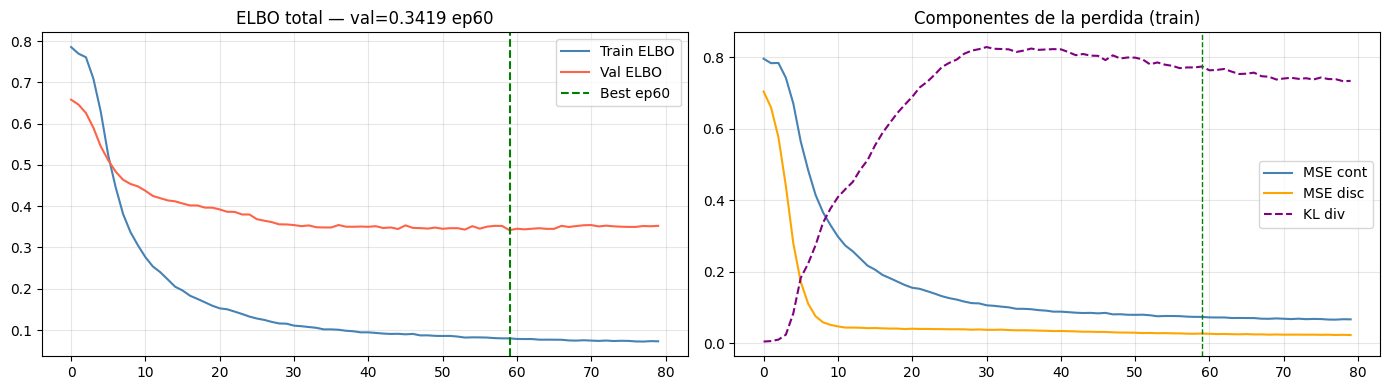

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_hist, label='Train ELBO', color='steelblue', lw=1.5)
axes[0].plot(val_hist,   label='Val ELBO',   color='tomato',    lw=1.5)
axes[0].axvline(best_ep-1, color='green', linestyle='--', lw=1.5, label=f'Best ep{best_ep}')
axes[0].set_title(f'ELBO total — val={best_val:.4f} ep{best_ep}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_mse_c, label='MSE cont', color='steelblue', lw=1.5)
axes[1].plot(hist_mse_d, label='MSE disc', color='orange',    lw=1.5)
axes[1].plot(hist_kl,    label='KL div',   color='purple',    lw=1.5, linestyle='--')
axes[1].axvline(best_ep-1, color='green', linestyle='--', lw=1)
axes[1].set_title('Componentes de la perdida (train)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'training_curve.png'), dpi=120, bbox_inches='tight')
plt.show()


## 7. Evaluacion con protocolo definitivo

### 7a. Construccion de ventanas con metadatos

Se incluye `attack_id` y `attack_name` por ventana para aplicar
la exclusion de ataques sigilosos.

In [11]:
# Escalar todo el CSV
df_eval_sc = df_all[['t_stamp', 'attack_label'] + feature_cols].copy()
df_eval_sc[feature_cols]    = df_eval_sc[feature_cols].fillna(modes_train)
df_eval_sc[continuous_cols] = np.clip(
    scaler_cont.transform(df_eval_sc[continuous_cols].values), -CLIP_VAL, CLIP_VAL
)
df_eval_sc[discrete_cols] = (df_eval_sc[discrete_cols] / disc_max).clip(0, 1)

cont_arr   = df_eval_sc[continuous_cols].values.astype(np.float32)
disc_arr   = df_eval_sc[discrete_cols].values.astype(np.float32)
labs_arr   = df_eval_sc['attack_label'].values
tstamp_arr = df_eval_sc['t_stamp'].values
aid_arr    = df_meta['attack_id'].values   if 'attack_id'   in df_meta.columns else np.zeros(len(df_meta))
aname_arr  = df_meta['attack_name'].values if 'attack_name' in df_meta.columns else np.full(len(df_meta), 'unknown')

wins_c, wins_d, meta_rows = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    seg_labs = labs_arr[s:s+WINDOW_SIZE]
    seg_aids = aid_arr[s:s+WINDOW_SIZE]
    seg_anms = aname_arr[s:s+WINDOW_SIZE]
    atk_ids  = seg_aids[seg_labs == 1]
    atk_nms  = seg_anms[seg_labs == 1]
    if len(atk_ids) > 0:
        uid, cnt = np.unique(atk_ids, return_counts=True); aid_mode = uid[cnt.argmax()]
        unm, cnm = np.unique(atk_nms, return_counts=True); anm_mode = unm[cnm.argmax()]
    else:
        aid_mode, anm_mode = 0, 'normal'
    meta_rows.append({'y': int(np.any(seg_labs==1)), 'attack_id': aid_mode,
                      'attack_name': str(anm_mode), 't_start': tstamp_arr[s],
                      'attack_frac': float(np.mean(seg_labs==1))})

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(np.array(wins_d, dtype=np.float32), discrete_cols).values.astype(np.float32)
df_wins  = pd.DataFrame(meta_rows)

print(f'Ventanas totales  : {len(df_wins):,}')
print(f'  Normal (y=0)    : {(df_wins["y"]==0).sum():,}')
print(f'  Ataque (y=1)    : {(df_wins["y"]==1).sum():,}  ({100*df_wins["y"].mean():.1f}%)')
print(f'  Tipos de ataque : {df_wins[df_wins["y"]==1]["attack_id"].nunique()}')


Ventanas totales  : 2,881
  Normal (y=0)    : 2,519
  Ataque (y=1)    : 362  (12.6%)
  Tipos de ataque : 11


### 7b. Scores y distribucion de referencia (todos los ataques)

[REFERENCIA — todos los ataques]
Error medio NORMAL: 0.1579
Error medio ATAQUE: 0.3821  (ratio: 2.42x)


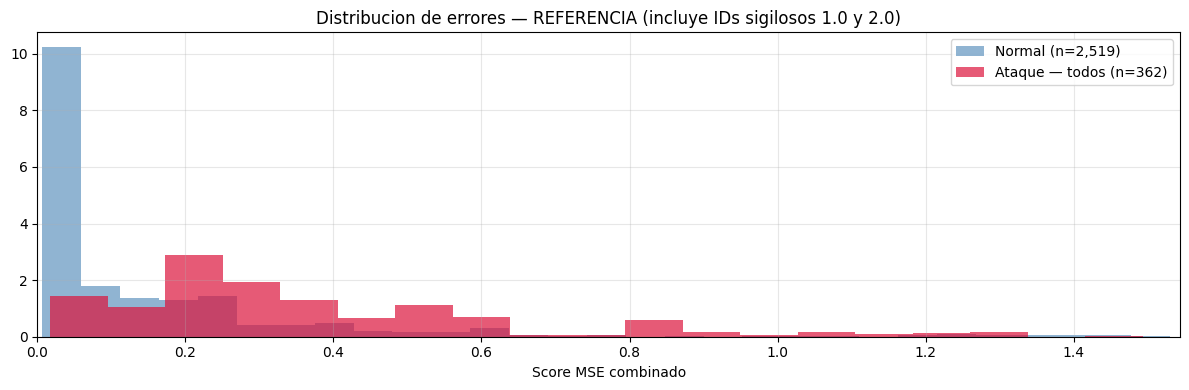

In [12]:
def recon_scores(model, Xc, Xd, alpha, bs=256):
    loader = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                      torch.tensor(Xd, dtype=torch.float32)),
                        batch_size=bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, _ = model(xc, xd)
            ec_l.extend(torch.mean((xc_hat-xc)**2, dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat-xd)**2, dim=1).cpu().numpy())
    ec = np.array(ec_l); ed = np.array(ed_l)
    return alpha * ec + (1 - alpha) * ed

scores   = recon_scores(model, X_eval_c, X_eval_d, ALPHA)
df_wins['score'] = scores
y_all    = df_wins['y'].values

mn_all = scores[y_all==0].mean(); ma_all = scores[y_all==1].mean()
print(f'[REFERENCIA — todos los ataques]')
print(f'Error medio NORMAL: {mn_all:.4f}')
print(f'Error medio ATAQUE: {ma_all:.4f}  (ratio: {ma_all/mn_all:.2f}x)')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(scores[y_all==0], bins=80, alpha=0.6, density=True, color='steelblue',
        label=f'Normal (n={(y_all==0).sum():,})')
ax.hist(scores[y_all==1], bins=40, alpha=0.7, density=True, color='crimson',
        label=f'Ataque — todos (n={(y_all==1).sum():,})')
ax.set_xlabel('Score MSE combinado')
ax.set_title('Distribucion de errores — REFERENCIA (incluye IDs sigilosos 1.0 y 2.0)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.percentile(scores, 99.5))
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'error_dist_referencia.png'), dpi=120, bbox_inches='tight')
plt.show()


### 7c. Aplicacion del protocolo definitivo

**Paso 1**: Excluir ventanas de ataques sigilosos (IDs 1.0 y 2.0).

**Paso 2**: Sweep de tau con filtro consecutivo k=3 para encontrar
el umbral optimo que maximiza F1.

**Paso 3**: Calcular metricas finales.

In [13]:
# Paso 1: exclusion
mask_keep = ~((df_wins['y']==1) & (df_wins['attack_id'].isin(EXCLUDED_IDS)))
df_filt   = df_wins[mask_keep].copy().reset_index(drop=True)
sc_filt   = scores[mask_keep.values]
y_filt    = df_filt['y'].values

print(f'Excluidas: {(~mask_keep).sum()} ventanas (IDs {EXCLUDED_IDS})')
print(f'Evaluacion filtrada: {len(df_filt):,} ventanas | '
      f'Normal: {(y_filt==0).sum():,} | Ataque: {(y_filt==1).sum():,}')
print()
print('Tipos de ataque en evaluacion filtrada:')
for aid, grp in df_filt[df_filt['y']==1].groupby('attack_id'):
    print(f'  ID {aid:.0f}: {grp["attack_name"].mode().iloc[0][:45]}  ({len(grp)} ventanas)')


Excluidas: 70 ventanas (IDs [1.0, 2.0])
Evaluacion filtrada: 2,811 ventanas | Normal: 2,519 | Ataque: 292

Tipos de ataque en evaluacion filtrada:
  ID 3: Florida Water Plant Scenario — Dosing Pump Ac  (35 ventanas)
  ID 4: Tank Overflow via LIT101 Spoofing — Schneider  (35 ventanas)
  ID 5: Stage 5 Valve Manipulation — MV503/504 Open,   (35 ventanas)
  ID 6: Tank Overflow via LIT101 Spoofing — Schneider  (15 ventanas)
  ID 7: Stage 2 Parallel Pump Override — MV201 Open,   (32 ventanas)
  ID 8: Reverse Osmosis Backwash Diversion — MV302 Cl  (35 ventanas)
  ID 9: Forced Backwash Trigger via DPIT301 Spoofing   (35 ventanas)
  ID 10: Multi-Value Level Oscillation — LIT601 Spoofi  (35 ventanas)
  ID 11: AIT402 High-Value Spoof Start – Using script  (35 ventanas)


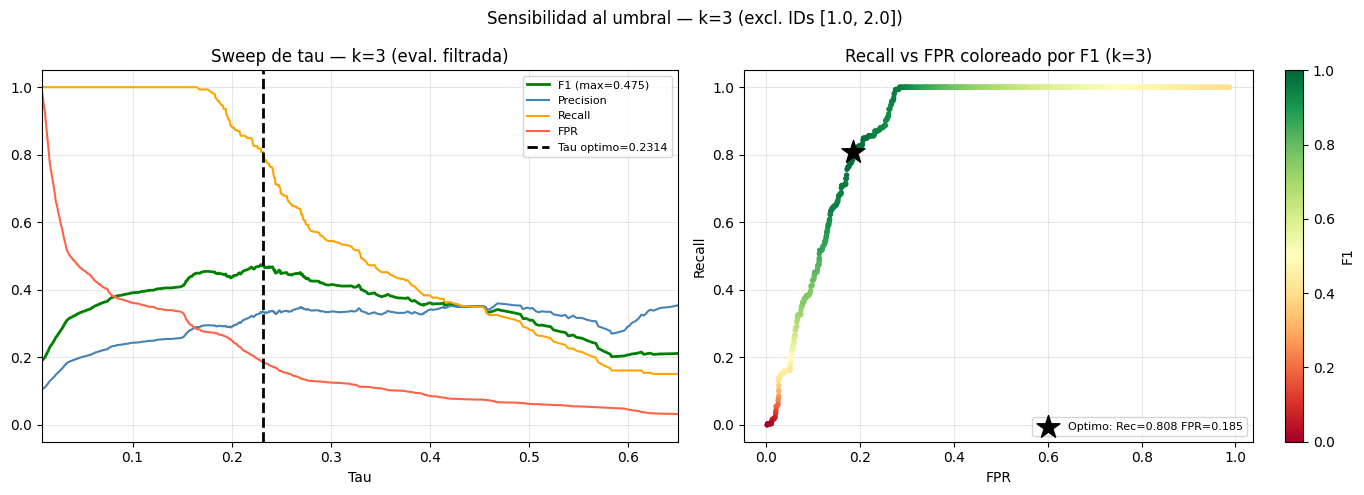

Tau optimo encontrado: 0.2314


In [14]:
# Paso 2: sweep de tau con k=3
def consecutive_filter(scores_arr, tau, k):
    raw = (scores_arr > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for i in range(k-1, len(raw)):
        out[i] = int(raw[i-k+1:i+1].all())
    return out

taus   = np.percentile(sc_filt, np.linspace(0.5, 99.5, 800))
sw_f1, sw_prec, sw_rec, sw_fpr = [], [], [], []
for tau in taus:
    pred = consecutive_filter(sc_filt, tau, CONSEC_K)
    tp = ((pred==1)&(y_filt==1)).sum(); fp = ((pred==1)&(y_filt==0)).sum()
    fn = ((pred==0)&(y_filt==1)).sum(); tn = ((pred==0)&(y_filt==0)).sum()
    p = tp/(tp+fp+1e-10); r = tp/(tp+fn+1e-10)
    sw_f1.append(2*p*r/(p+r+1e-10))
    sw_prec.append(p); sw_rec.append(r); sw_fpr.append(fp/(fp+tn+1e-10))

sw_f1 = np.array(sw_f1)
best_idx = sw_f1.argmax()
TAU_OPT  = float(taus[best_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(taus, sw_f1,          color='green',     lw=2,   label=f'F1 (max={sw_f1.max():.3f})')
axes[0].plot(taus, sw_prec,        color='steelblue', lw=1.5, label='Precision')
axes[0].plot(taus, sw_rec,         color='orange',    lw=1.5, label='Recall')
axes[0].plot(taus, sw_fpr,         color='tomato',    lw=1.5, label='FPR')
axes[0].axvline(TAU_OPT, color='black', lw=2, linestyle='--', label=f'Tau optimo={TAU_OPT:.4f}')
axes[0].set_xlabel('Tau'); axes[0].set_xlim(taus[0], np.percentile(sc_filt, 95))
axes[0].set_title(f'Sweep de tau — k={CONSEC_K} (eval. filtrada)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

sc_map = plt.cm.RdYlGn(sw_f1 / (sw_f1.max()+1e-10))
axes[1].scatter(sw_fpr, sw_rec, c=sw_f1, cmap='RdYlGn', s=8, zorder=3)
axes[1].scatter(sw_fpr[best_idx], sw_rec[best_idx],
                marker='*', s=300, color='black', zorder=5,
                label=f'Optimo: Rec={sw_rec[best_idx]:.3f} FPR={sw_fpr[best_idx]:.3f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('Recall')
axes[1].set_title(f'Recall vs FPR coloreado por F1 (k={CONSEC_K})')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.colorbar(plt.cm.ScalarMappable(cmap='RdYlGn'), ax=axes[1], label='F1')

plt.suptitle(f'Sensibilidad al umbral — k={CONSEC_K} (excl. IDs {EXCLUDED_IDS})', fontsize=12)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'tau_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Tau optimo encontrado: {TAU_OPT:.4f}')


In [15]:
# Paso 3: metricas finales
pred_final = consecutive_filter(sc_filt, TAU_OPT, CONSEC_K)
tp = int(((pred_final==1)&(y_filt==1)).sum())
fp = int(((pred_final==1)&(y_filt==0)).sum())
fn = int(((pred_final==0)&(y_filt==1)).sum())
tn = int(((pred_final==0)&(y_filt==0)).sum())
prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
f1   = 2*prec*rec/(prec+rec+1e-10)
fpr  = fp/(fp+tn+1e-10)
auc_filt   = roc_auc_score(y_filt, sc_filt)
pr_auc_filt= average_precision_score(y_filt, sc_filt)

# Metricas de referencia sin filtro (para documentacion)
auc_ref = roc_auc_score(y_all, scores)

print('=' * 60)
print('METRICAS BASELINE DEFINITIVAS')
print('=' * 60)
print(f'  Protocolo : excl. IDs {EXCLUDED_IDS} | k={CONSEC_K} | tau={TAU_OPT:.4f}')
print()
print(f'  ROC-AUC  : {auc_filt:.4f}   PR-AUC  : {pr_auc_filt:.4f}')
print(f'  F1       : {f1:.3f}     Recall  : {rec:.3f}')
print(f'  Precision: {prec:.3f}     FPR     : {fpr:.3f}')
print(f'  TP={tp} | FP={fp} | FN={fn} | TN={tn}')
print()
print(f'  [Ref. sin filtro, todos los ataques] ROC-AUC: {auc_ref:.4f}')
print('=' * 60)


METRICAS BASELINE DEFINITIVAS
  Protocolo : excl. IDs [1.0, 2.0] | k=3 | tau=0.2314

  ROC-AUC  : 0.8751   PR-AUC  : 0.3138
  F1       : 0.475     Recall  : 0.808
  Precision: 0.336     FPR     : 0.185
  TP=236 | FP=466 | FN=56 | TN=2053

  [Ref. sin filtro, todos los ataques] ROC-AUC: 0.7963


### 7d. Graficos de evaluacion

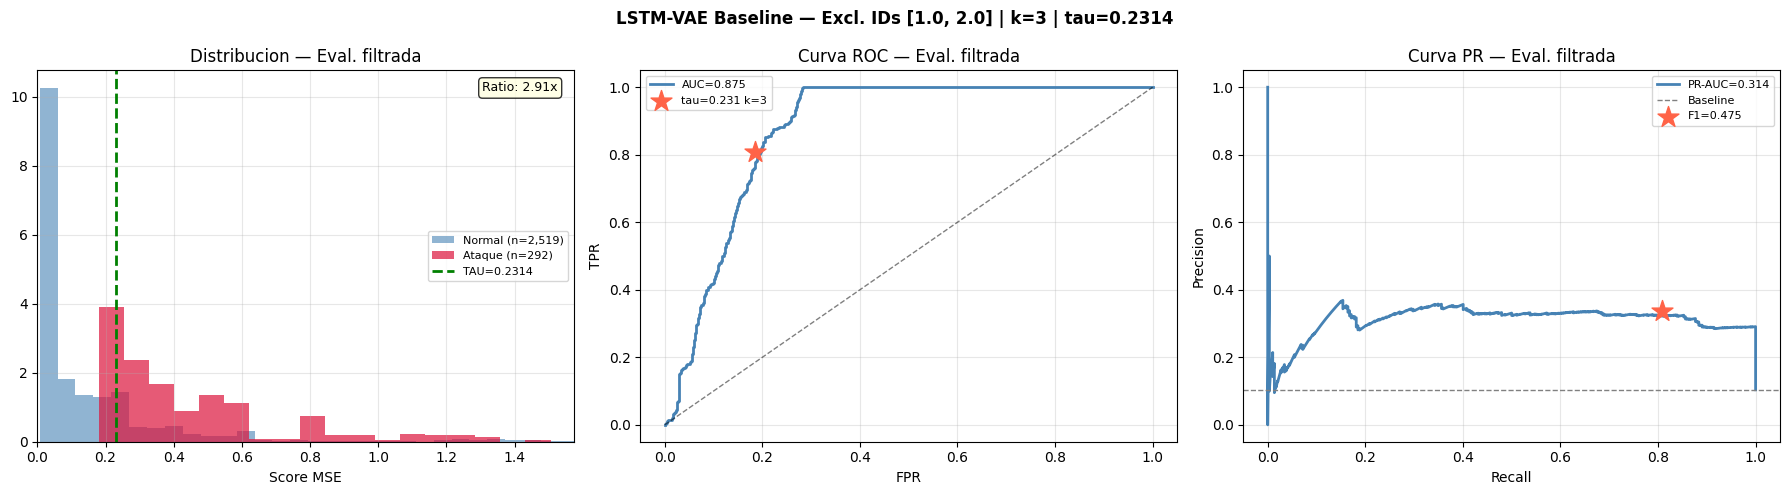

In [16]:
# Distribucion filtrada + curvas ROC/PR
fprs_c, tprs_c, _ = roc_curve(y_filt, sc_filt)
precs_c, recs_c, _ = precision_recall_curve(y_filt, sc_filt)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribucion filtrada
mn_f = sc_filt[y_filt==0].mean(); ma_f = sc_filt[y_filt==1].mean()
axes[0].hist(sc_filt[y_filt==0], bins=80, alpha=0.6, density=True, color='steelblue',
             label=f'Normal (n={(y_filt==0).sum():,})')
axes[0].hist(sc_filt[y_filt==1], bins=40, alpha=0.7, density=True, color='crimson',
             label=f'Ataque (n={(y_filt==1).sum():,})')
axes[0].axvline(TAU_OPT, color='green', lw=2, linestyle='--', label=f'TAU={TAU_OPT:.4f}')
axes[0].set_xlabel('Score MSE'); axes[0].set_title('Distribucion — Eval. filtrada')
axes[0].text(0.97, 0.97, f'Ratio: {ma_f/mn_f:.2f}x', ha='right', va='top',
             transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, np.percentile(sc_filt, 99.5))

# ROC
axes[1].plot(fprs_c, tprs_c, color='steelblue', lw=2, label=f'AUC={auc_filt:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[1].scatter(fpr, rec, marker='*', s=250, color='tomato', zorder=5,
                label=f'tau={TAU_OPT:.3f} k={CONSEC_K}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC — Eval. filtrada')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# PR
axes[2].plot(recs_c, precs_c, color='steelblue', lw=2, label=f'PR-AUC={pr_auc_filt:.3f}')
axes[2].axhline(y_filt.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].scatter(rec, prec, marker='*', s=250, color='tomato', zorder=5,
                label=f'F1={f1:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Curva PR — Eval. filtrada')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'LSTM-VAE Baseline — Excl. IDs {EXCLUDED_IDS} | k={CONSEC_K} | tau={TAU_OPT:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'eval_dist_roc_pr.png'), dpi=120, bbox_inches='tight')
plt.show()


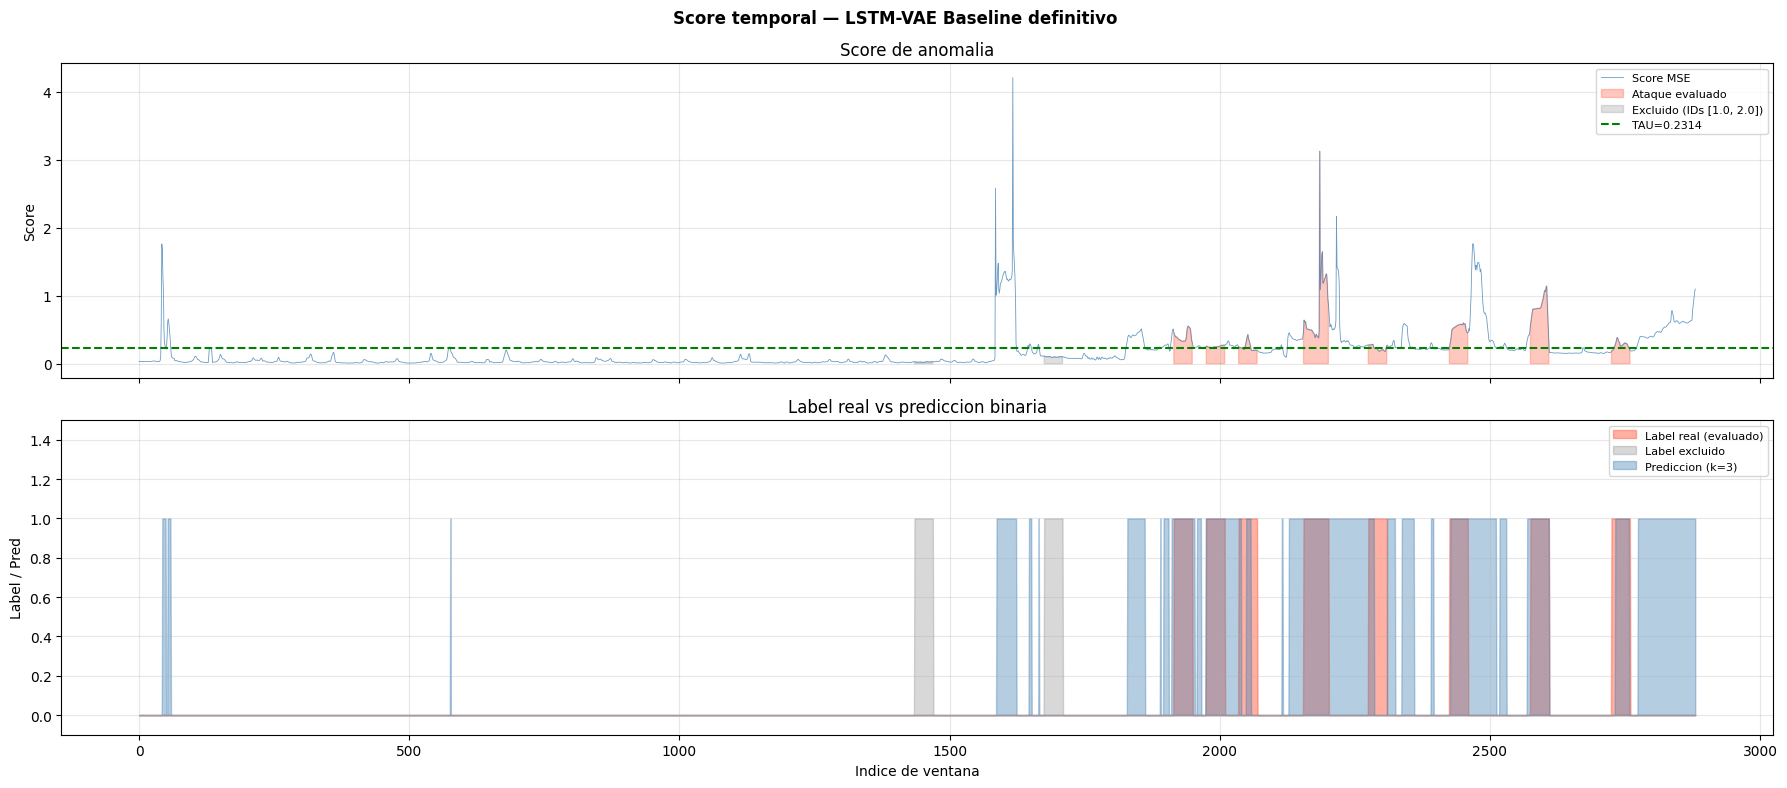

In [17]:
# Score temporal
t = np.arange(len(df_wins))
pred_all_k = consecutive_filter(scores, TAU_OPT, CONSEC_K)
excl_mask  = ((df_wins['y']==1) & (df_wins['attack_id'].isin(EXCLUDED_IDS))).values

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

axes[0].plot(t, scores, color='steelblue', lw=0.6, alpha=0.8, label='Score MSE')
axes[0].fill_between(t, 0, scores, where=(y_all==1) & ~excl_mask,
                     color='tomato', alpha=0.35, label='Ataque evaluado')
axes[0].fill_between(t, 0, scores, where=excl_mask,
                     color='gray', alpha=0.25, label=f'Excluido (IDs {EXCLUDED_IDS})')
axes[0].axhline(TAU_OPT, color='green', lw=1.5, linestyle='--', label=f'TAU={TAU_OPT:.4f}')
axes[0].set_ylabel('Score'); axes[0].set_title('Score de anomalia')
axes[0].legend(fontsize=8, loc='upper right'); axes[0].grid(True, alpha=0.3)

axes[1].fill_between(t, 0, y_all.astype(float) * ~excl_mask,
                     color='tomato', alpha=0.5, label='Label real (evaluado)')
axes[1].fill_between(t, 0, excl_mask.astype(float),
                     color='gray', alpha=0.3, label='Label excluido')
axes[1].fill_between(t, 0, pred_all_k.astype(float),
                     color='steelblue', alpha=0.4, label=f'Prediccion (k={CONSEC_K})')
axes[1].set_xlabel('Indice de ventana'); axes[1].set_ylabel('Label / Pred')
axes[1].set_title('Label real vs prediccion binaria')
axes[1].set_ylim(-0.1, 1.5)
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(True, alpha=0.3)

plt.suptitle('Score temporal — LSTM-VAE Baseline definitivo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'score_temporal.png'), dpi=120, bbox_inches='tight')
plt.show()


In [18]:
# Tabla de deteccion por tipo de ataque
print('Deteccion por tipo de ataque (tau optimo, k=3):')
print(f'{"ID":>5}  {"Nombre":45}  {"Ventanas":>8}  {"Det."+" (%)": >12}  {"Score med.":>10}')
print('-' * 90)
for aid, grp in df_wins[df_wins['y']==1].sort_values('attack_id').groupby('attack_id'):
    n_tot   = len(grp)
    pred_g  = consecutive_filter(grp['score'].values, TAU_OPT, CONSEC_K)
    n_det   = int(pred_g.sum())
    excluido= aid in EXCLUDED_IDS
    tag     = '  [EXCLUIDO]' if excluido else ''
    name    = grp['attack_name'].mode().iloc[0][:43]
    print(f'{aid:>5.0f}  {name:45}  {n_tot:>8}  {n_det:>6} ({100*n_det/n_tot:5.1f}%)  '
          f'{grp["score"].mean():>10.4f}{tag}')


Deteccion por tipo de ataque (tau optimo, k=3):
   ID  Nombre                                         Ventanas      Det. (%)  Score med.
------------------------------------------------------------------------------------------
    1  Stage 5 Valve Manipulation — MV503/504 Open          35       0 (  0.0%)      0.0239  [EXCLUIDO]
    2  Stage 1 Flow Disruption — MV101 Open, P101           35       0 (  0.0%)      0.0996  [EXCLUIDO]
    3  Florida Water Plant Scenario — Dosing Pump           35      33 ( 94.3%)      0.3988
    4  Tank Overflow via LIT101 Spoofing — Schneid          35      33 ( 94.3%)      0.2515
    5  Stage 5 Valve Manipulation — MV503/504 Open          35      12 ( 34.3%)      0.2498
    6  Tank Overflow via LIT101 Spoofing — Schneid          15      13 ( 86.7%)      0.5344
    7  Stage 2 Parallel Pump Override — MV201 Open          32      30 ( 93.8%)      0.9286
    8  Reverse Osmosis Backwash Diversion — MV302           35       9 ( 25.7%)      0.2272
    9  Force

## 8. Guardar artefactos

In [19]:
torch.save(model.state_dict(), SAVE_DIR / 'model_state.pt')

# tau_dict con el umbral definitivo
tau_dict = {f'p{str(p).replace(".","_")}': float(np.percentile(scores[y_all==0], p))
            for p in [90, 95, 97.5, 99, 99.5]}
tau_dict['optimal_filtered'] = TAU_OPT  # umbral definitivo
with open(SAVE_DIR / 'tau_dict.json', 'w') as f:
    json.dump(tau_dict, f, indent=4)

with open(SAVE_DIR / 'columns_config.json', 'w') as f:
    json.dump({'continuous_cols': continuous_cols,
               'discrete_cols':   discrete_cols,
               'feature_cols':    feature_cols}, f, indent=4)

config = {
    'version'           : 'lstm_vae_a12_baseline_v1',
    'dataset'           : 'SWaT A12 Mar 2026',
    'architecture'      : 'LSTM-VAE Hybrid (Optuna trial #2)',
    'optuna_source'     : 'lstm_vae_a12_optuna_v1 / trial #2 / AUC=0.7946',
    'split'             : 'chronological_60_20_20',
    'window_size'       : WINDOW_SIZE,
    'stride'            : STRIDE,
    'clip_val'          : CLIP_VAL,
    'score_formula'     : 'alpha*MSE_cont + (1-alpha)*MSE_disc  [KL solo en train]',
    'model_params'      : {
        'hidden_size' : HIDDEN_SIZE, 'num_layers': NUM_LAYERS,
        'latent_dim'  : LATENT_DIM,  'disc_hidden': DISC_HIDDEN,
        'alpha'       : float(ALPHA),'beta': float(BETA),
        'dropout'     : float(DROPOUT),'lr': float(LR), 'batch_size': BATCH_SIZE,
    },
    'training'          : {'best_epoch': best_ep, 'best_val_loss': float(best_val),
                           'max_epochs': MAX_EPOCHS, 'patience': PATIENCE},
    'eval_protocol'     : {
        'excluded_attack_ids' : EXCLUDED_IDS,
        'exclusion_reason'    : (
            'Ataques fisicos sigilosos dentro del envelope estadistico normal. '
            'Indetectables con reconstruccion no supervisada '
            '[Taormina et al. 2018; Goh et al. 2017].'
        ),
        'consecutive_k'       : CONSEC_K,
        'tau_optimal'         : TAU_OPT,
        'tau_search'          : 'sweep 800 puntos sobre percentiles 0.5-99.5 del set filtrado',
    },
    'metrics_reference' : {   # todos los ataques, sin filtro
        'roc_auc' : float(auc_ref),
    },
    'metrics_baseline'  : {   # protocolo definitivo
        'roc_auc'   : float(auc_filt),
        'pr_auc'    : float(pr_auc_filt),
        'f1'        : float(f1),
        'recall'    : float(rec),
        'precision' : float(prec),
        'fpr'       : float(fpr),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
    },
    'continuous_cols'   : continuous_cols,
    'discrete_cols'     : discrete_cols,
    'feature_cols'      : feature_cols,
    'scenarios'         : ['real_only', 'synthetic_only', 'real_plus_synthetic'],
}
with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=4)

print('Artefactos guardados en:', SAVE_DIR.resolve())
for fp in sorted(SAVE_DIR.iterdir()): print(f'  {fp.name}')
print()
print('=== RESUMEN FINAL ===')
print(f'  ROC-AUC   : {auc_filt:.4f}  |  PR-AUC    : {pr_auc_filt:.4f}')
print(f'  F1        : {f1:.3f}   |  Recall    : {rec:.3f}')
print(f'  Precision : {prec:.3f}   |  FPR       : {fpr:.3f}')
print(f'  tau optimo: {TAU_OPT:.4f}  |  k         : {CONSEC_K}')
print(f'  Excluidos : IDs {EXCLUDED_IDS}')


Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_baseline_v1
  columns_config.json
  config.json
  disc_max_dict.pkl
  error_dist_referencia.png
  eval_dist_roc_pr.png
  model_state.pt
  scaler_cont.pkl
  score_temporal.png
  tau_dict.json
  tau_sweep.png
  training_curve.png

=== RESUMEN FINAL ===
  ROC-AUC   : 0.8751  |  PR-AUC    : 0.3138
  F1        : 0.475   |  Recall    : 0.808
  Precision : 0.336   |  FPR       : 0.185
  tau optimo: 0.2314  |  k         : 3
  Excluidos : IDs [1.0, 2.0]
